In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, TensorDataset
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score, f1_score
import time
import pandas as pd
import seaborn as sns

# Load & Preprocess

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])


trainval_set = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_set = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

100%|██████████| 170M/170M [29:01<00:00, 97.9kB/s]


In [3]:
def flatten_dataset(dataset):
    images = torch.stack([data[0] for data in dataset])  # shape: [N, 3, 32, 32]
    labels = torch.tensor([data[1] for data in dataset])  # shape: [N]
    images_flat = images.view(images.shape[0], -1)       # shape: [N, 3072]
    return TensorDataset(images_flat, labels)

trainval_dataset = flatten_dataset(trainval_set)
test_dataset = flatten_dataset(test_set)

In [4]:
train_size = int(0.8 * len(trainval_dataset))
val_size = len(trainval_dataset) - train_size
train_dataset, val_dataset = random_split(trainval_dataset, [train_size, val_size])

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

class_names = trainval_set.classes

In [5]:
print(f"Train set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")

print(f"Train loader batches: {len(train_loader)}")
print(f"Validation loader batches: {len(val_loader)}")
print(f"Test loader batches: {len(test_loader)}")

print("Class labels:", class_names)

Train set size: 40000
Validation set size: 10000
Test set size: 10000
Train loader batches: 625
Validation loader batches: 157
Test loader batches: 157
Class labels: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [6]:
# Check dataset flattening and class names
CT_first_batch = next(iter(train_loader))       # Get first batch from train_loader
CT_batch_features, CT_batch_labels = CT_first_batch

CT_Class_names = class_names

# Print shapes
print("CT_Batch feature shape:", CT_batch_features.shape)   # Expect [64, 3072]
print("CT_Batch label shape:", CT_batch_labels.shape)       # Expect [64]

# Print class names
print("CT_Class names:", CT_Class_names)

CT_Batch feature shape: torch.Size([64, 3072])
CT_Batch label shape: torch.Size([64])
CT_Class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [7]:
class BaselineDeepMLP(nn.Module):
    def __init__(self, input_dim=3072, output_dim=10):
        super(BaselineDeepMLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim)  # output logits
        )

    def forward(self, x):
        return self.model(x)

# Instantiate the model and move to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_baseline = BaselineDeepMLP().to(device)

# Check summary
print(model_baseline)


BaselineDeepMLP(
  (model): Sequential(
    (0): Linear(in_features=3072, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): ReLU()
    (8): Linear(in_features=128, out_features=128, bias=True)
    (9): ReLU()
    (10): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_baseline.parameters(), lr=0.01)

# Tracking metrics
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

epochs = 20

for epoch in range(epochs):
    model_baseline.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model_baseline(images)

        # Compute loss
        loss = criterion(outputs, labels)

        # Backpropagation and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Accumulate metrics
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # Validation phase
    model_baseline.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model_baseline(images)

            # Compute loss
            loss = criterion(outputs, labels)

            # Accumulate metrics
            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    val_losses.append(val_loss / val_total)
    val_accuracies.append(val_correct / val_total)

    # Print epoch summary
    print(f"Epoch [{epoch+1}/{epochs}] - "
          f"Train Loss: {train_loss:.4f}, Accuracy: {train_acc:.4f} | "
          f"Val Loss: {val_losses[-1]:.4f}, Accuracy: {val_accuracies[-1]:.4f}")


Epoch [1/20] - Train Loss: 2.3021, Accuracy: 0.1224 | Val Loss: 2.3013, Accuracy: 0.1348
Epoch [2/20] - Train Loss: 2.2987, Accuracy: 0.1561 | Val Loss: 2.2954, Accuracy: 0.1760
Epoch [3/20] - Train Loss: 2.2766, Accuracy: 0.1834 | Val Loss: 2.2331, Accuracy: 0.1733
Epoch [4/20] - Train Loss: 2.1581, Accuracy: 0.1905 | Val Loss: 2.1071, Accuracy: 0.1978
Epoch [5/20] - Train Loss: 2.0498, Accuracy: 0.2238 | Val Loss: 2.0051, Accuracy: 0.2400
Epoch [6/20] - Train Loss: 1.9387, Accuracy: 0.2695 | Val Loss: 1.8964, Accuracy: 0.2797
Epoch [7/20] - Train Loss: 1.8531, Accuracy: 0.3002 | Val Loss: 1.8440, Accuracy: 0.3024
Epoch [8/20] - Train Loss: 1.8013, Accuracy: 0.3264 | Val Loss: 1.8006, Accuracy: 0.3224
Epoch [9/20] - Train Loss: 1.7579, Accuracy: 0.3467 | Val Loss: 1.7595, Accuracy: 0.3459
Epoch [10/20] - Train Loss: 1.7058, Accuracy: 0.3729 | Val Loss: 1.7192, Accuracy: 0.3640
Epoch [11/20] - Train Loss: 1.6372, Accuracy: 0.4049 | Val Loss: 1.6401, Accuracy: 0.4107
Epoch [12/20] - Tra

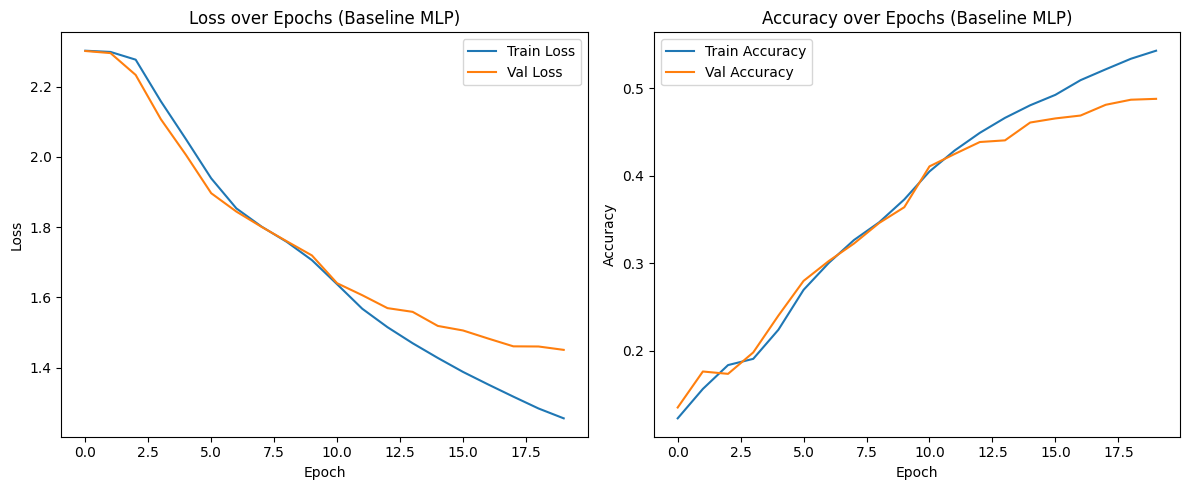

In [9]:
plt.figure(figsize=(12, 5))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Loss over Epochs (Baseline MLP)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Val Accuracy")
plt.title("Accuracy over Epochs (Baseline MLP)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

>What Did We Observe?

- **Training Loss** steadily decreased across epochs — showing that the model is learning from the data.
- **Validation Loss** initially followed training loss but later **flattened and fluctuated**, a common sign of **overfitting or unstable generalization**.
- **Accuracy curves** tell a similar story:
  - **Training Accuracy** continued to improve smoothly.
  - **Validation Accuracy** rose at first but then **plateaued or dipped**, failing to match the training performance.

> >**Challenges Observed in the Baseline Model**

| Issue                     | What We Saw                                   | Why It Matters                           |
|--------------------------|-----------------------------------------------|------------------------------------------|
| **Slow Convergence**     | Gradual improvement in loss and accuracy      | Training takes longer, inefficient learning |
| **Overfitting Signals**  | Train accuracy >> Val accuracy after some epochs | Model may not generalize well             |
| **Fluctuating Validation** | Val loss/accuracy bounce around mid-training | Model may be sensitive to noise or lack regularization |
| **Poor Gradient Flow**   | Especially in early layers (as seen in NB02)  | Some layers may not be learning at all   |

</br>

>Why This Baseline Is Important

This baseline highlights **real pain points** in training deep MLPs:
- No **Batch Normalization** → unstable training dynamics.
- No **weight regularization** → overfitting kicks in early.
- Simple **SGD optimizer** → slower adaptation compared to modern optimizers.

It gives us a solid reference point for improvement.

In [10]:
CT_total_params_baseline = sum(p.numel() for p in model_baseline.parameters() if p.requires_grad)

print("CT_Total trainable parameters (Baseline MLP):", CT_total_params_baseline)

CT_Total trainable parameters (Baseline MLP): 460682


# Batch Normalization

In [11]:
class MLP_BatchNorm(nn.Module):
    def __init__(self, input_dim=3072, output_dim=10):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.Linear(128, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.Linear(128, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.Linear(128, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.Linear(128, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.Linear(128, output_dim)  # output logits
        )

    def forward(self, x):
        return self.model(x)

# Instantiate model and optimizer
model_bn = MLP_BatchNorm().to(device)

In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_bn.parameters(), lr=0.01)

# Tracking
train_losses_bn, val_losses_bn = [], []
train_accs_bn, val_accs_bn = [], []

epochs = 20

for epoch in range(epochs):
    model_bn.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model_bn(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_losses_bn.append(running_loss / total)
    train_accs_bn.append(correct / total)

    # Validation
    model_bn.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_bn(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    val_losses_bn.append(val_loss / val_total)
    val_accs_bn.append(val_correct / val_total)

    print(f"Epoch [{epoch+1}/{epochs}] - "
          f"Train Acc: {train_accs_bn[-1]:.4f}, Val Acc: {val_accs_bn[-1]:.4f}")

Epoch [1/20] - Train Acc: 0.3619, Val Acc: 0.4244
Epoch [2/20] - Train Acc: 0.4508, Val Acc: 0.4567
Epoch [3/20] - Train Acc: 0.4901, Val Acc: 0.4755
Epoch [4/20] - Train Acc: 0.5201, Val Acc: 0.4834
Epoch [5/20] - Train Acc: 0.5397, Val Acc: 0.4989
Epoch [6/20] - Train Acc: 0.5558, Val Acc: 0.5035
Epoch [7/20] - Train Acc: 0.5714, Val Acc: 0.5073
Epoch [8/20] - Train Acc: 0.5899, Val Acc: 0.5017
Epoch [9/20] - Train Acc: 0.6012, Val Acc: 0.5100
Epoch [10/20] - Train Acc: 0.6122, Val Acc: 0.5100
Epoch [11/20] - Train Acc: 0.6273, Val Acc: 0.5154
Epoch [12/20] - Train Acc: 0.6391, Val Acc: 0.5063
Epoch [13/20] - Train Acc: 0.6487, Val Acc: 0.5061
Epoch [14/20] - Train Acc: 0.6581, Val Acc: 0.5120
Epoch [15/20] - Train Acc: 0.6672, Val Acc: 0.5179
Epoch [16/20] - Train Acc: 0.6763, Val Acc: 0.5094
Epoch [17/20] - Train Acc: 0.6873, Val Acc: 0.5189
Epoch [18/20] - Train Acc: 0.6930, Val Acc: 0.5130
Epoch [19/20] - Train Acc: 0.7032, Val Acc: 0.5077
Epoch [20/20] - Train Acc: 0.7089, Val A

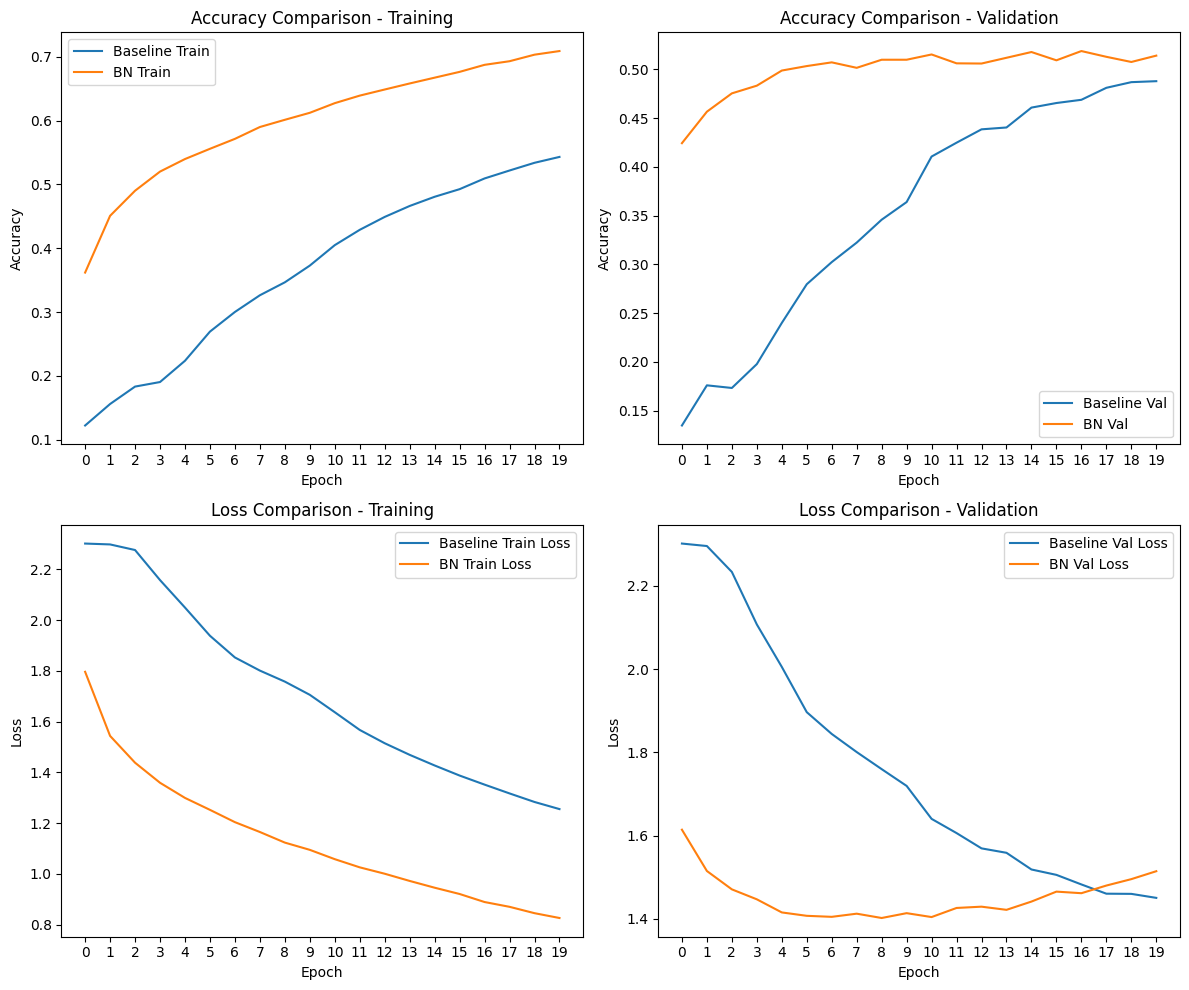

In [13]:
plt.figure(figsize=(12, 10))

# Accuracy
plt.subplot(2, 2, 1)
plt.plot(train_accuracies, label="Baseline Train")
plt.plot(train_accs_bn, label="BN Train")
plt.title("Accuracy Comparison - Training")
plt.xticks(range(epochs))  # Ensures ticks are integers from 0 to num_epochs - 1
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Accuracy
plt.subplot(2, 2, 2)
plt.plot(val_accuracies, label="Baseline Val")
plt.plot(val_accs_bn, label="BN Val")
plt.title("Accuracy Comparison - Validation")
plt.xticks(range(epochs))  # Ensures ticks are integers from 0 to num_epochs - 1
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(2, 2, 3)
plt.plot(train_losses, label="Baseline Train Loss")
plt.plot(train_losses_bn, label="BN Train Loss")
plt.title("Loss Comparison - Training")
plt.xticks(range(epochs))  # Ensures ticks are integers from 0 to num_epochs - 1
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Loss
plt.subplot(2, 2, 4)
plt.plot(val_losses, label="Baseline Val Loss")
plt.plot(val_losses_bn, label="BN Val Loss")
plt.title("Loss Comparison - Validation")
plt.xticks(range(epochs))  # Ensures ticks are integers from 0 to num_epochs - 1
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


Let’s interpret the comparison plots above:

- **Faster convergence**: The model with BatchNorm reaches higher accuracy **much earlier** than the baseline, both on training and validation sets.

- **Smoother training**: Training and validation **loss curves are more stable**, showing reduced noise and more consistent learning.

- **Better generalization**: The BatchNorm model not only trains faster — it also **achieves higher validation accuracy**, especially in early epochs. That means it’s learning patterns that **generalize better to unseen data**.

>**💡 Why Does BatchNorm Help?**

Batch Normalization improves training dynamics in several ways:

| Mechanism                        |  How It Helps                                                    |
|------------------------------------|---------------------------------------------------------------------|
| **Normalizes activations**         | Keeps inputs to each layer in a **similar range** — avoids instability |
| **Reduces internal covariate shift** | Makes each layer less sensitive to changes in the previous layers   |
| **Stabilizes gradient flow**       | Avoids vanishing/exploding gradients — helps deeper layers learn    |
| **Acts like regularization**       | Adds noise during training — reduces overfitting slightly           |

</br>

Even though we didn’t change the optimizer or learning rate, **just inserting BatchNorm** dramatically improved the MLP’s training behavior.

**Note**: We did **not add Dropout or L2 yet**, and we’re still using **vanilla SGD** — so the gains we see are purely due to BatchNorm.

 Up next: Let’s explore how **different optimizers** like **Adam** and **RMSProp** affect training speed and stability.

In [14]:
CT_bn_layers = [m for m in model_bn.modules() if isinstance(m, nn.BatchNorm1d)]
print("CT_Number of BatchNorm layers:", len(CT_bn_layers))

# Print details of the first BatchNorm layer
if len(CT_bn_layers) > 0:
    CT_First_BatchNorm_layer = CT_bn_layers[0]
    print("CT_First BatchNorm layer:", CT_First_BatchNorm_layer)

CT_Number of BatchNorm layers: 5
CT_First BatchNorm layer: BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)


# Optimizers


In [16]:
def train_model_with_optimizer(optimizer_name="SGD", epochs=10, seed=42):
    model = MLP_BatchNorm().to(device)
    criterion = nn.CrossEntropyLoss()

    # Choose optimizer
    if optimizer_name == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=0.01)
    elif optimizer_name == "SGD_momentum":
        optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    elif optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=0.001)
    elif optimizer_name == "RMSProp":
        optimizer = optim.RMSprop(model.parameters(), lr=0.001)
    else:
        raise ValueError("Unsupported optimizer")

    # Tracking
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    # Training loop
    for epoch in range(epochs):
        model.train()
        train_loss_epoch, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss_epoch += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_losses.append(train_loss_epoch / total)
        train_accuracies.append(correct / total)

        # Validation phase
        model.eval()
        val_loss_epoch, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss_epoch += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_losses.append(val_loss_epoch / val_total)
        val_accuracies.append(val_correct / val_total)

        # Print progress
        print(f"[{optimizer_name}] Epoch {epoch+1}/{epochs} - "
              f"Train Acc: {train_accuracies[-1]:.4f}, Val Acc: {val_accuracies[-1]:.4f}")

    return train_losses, val_losses, train_accuracies, val_accuracies, model


In [17]:
# Train with all optimizers
eval_opt_results = {}
for opt in ["SGD", "SGD_momentum", "Adam", "RMSProp"]:
    print(f"\n Training with {opt}")
    eval_opt_results[opt] = train_model_with_optimizer(optimizer_name=opt, epochs=20)


 Training with SGD
[SGD] Epoch 1/20 - Train Acc: 0.3668, Val Acc: 0.4334
[SGD] Epoch 2/20 - Train Acc: 0.4524, Val Acc: 0.4576
[SGD] Epoch 3/20 - Train Acc: 0.4876, Val Acc: 0.4789
[SGD] Epoch 4/20 - Train Acc: 0.5147, Val Acc: 0.4843
[SGD] Epoch 5/20 - Train Acc: 0.5336, Val Acc: 0.4892
[SGD] Epoch 6/20 - Train Acc: 0.5545, Val Acc: 0.4915
[SGD] Epoch 7/20 - Train Acc: 0.5686, Val Acc: 0.5069
[SGD] Epoch 8/20 - Train Acc: 0.5842, Val Acc: 0.5056
[SGD] Epoch 9/20 - Train Acc: 0.5982, Val Acc: 0.5120
[SGD] Epoch 10/20 - Train Acc: 0.6135, Val Acc: 0.5093
[SGD] Epoch 11/20 - Train Acc: 0.6207, Val Acc: 0.5115
[SGD] Epoch 12/20 - Train Acc: 0.6362, Val Acc: 0.5190
[SGD] Epoch 13/20 - Train Acc: 0.6438, Val Acc: 0.5104
[SGD] Epoch 14/20 - Train Acc: 0.6576, Val Acc: 0.5174
[SGD] Epoch 15/20 - Train Acc: 0.6667, Val Acc: 0.5101
[SGD] Epoch 16/20 - Train Acc: 0.6748, Val Acc: 0.5157
[SGD] Epoch 17/20 - Train Acc: 0.6821, Val Acc: 0.5104
[SGD] Epoch 18/20 - Train Acc: 0.6896, Val Acc: 0.5109

Based on the plots comparing `SGD`, `SGD + momentum`, `Adam`, and `RMSProp`, here’s what we observe:

**1. Training Loss (Top-Left Plot)**

- **Adam** and **RMSProp** show the **fastest and smoothest decrease** in training loss.
- **SGD + Momentum** improves over plain SGD, but still trails behind adaptive methods.
- **SGD** converges slowly — it struggles to efficiently update weights in deep networks.

**2. Validation Loss (Top-Right Plot)**

- All optimizers improve early on, but:
  - **Adam** and **RMSProp** reach **lower validation loss** faster.
  - **SGD** has **higher and more unstable** validation loss over time.
- After ~10 epochs, most curves start to **plateau or rise**, hinting at early **overfitting**.

**3. Training Accuracy (Bottom-Left Plot)**

- **Adam** and **RMSProp** again outperform others in training accuracy.
- **SGD + Momentum** makes a clear improvement over plain SGD.
- **SGD** stays behind — its updates are slower and less effective.

**4. Validation Accuracy (Bottom-Right Plot)**

- **Adam** and **RMSProp** achieve the **best final accuracy**, peaking around **0.54**.
- **SGD + Momentum** follows closely and performs respectably.
- **SGD** levels off early — showing weaker generalization.

In [18]:
for opt_name, results in eval_opt_results.items():
    CT_val_acc_final = results[3][-1]
    print(f"CT_Optimizer: {opt_name} | Final Val Accuracy: {CT_val_acc_final:.4f}")

CT_Optimizer: SGD | Final Val Accuracy: 0.5096
CT_Optimizer: SGD_momentum | Final Val Accuracy: 0.5340
CT_Optimizer: Adam | Final Val Accuracy: 0.5260
CT_Optimizer: RMSProp | Final Val Accuracy: 0.5272


# Add Dropout + L2 Regularization

In [19]:
class MLP_With_Dropout(nn.Module):
    def __init__(self, input_dim=3072, hidden_dim=128, output_dim=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)


In [20]:
def train_dropout_l2_model(epochs=10, weight_decay=1e-4):
    torch.manual_seed(42)  # For reproducibility

    model = MLP_With_Dropout().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=weight_decay)

    train_loss, val_loss = [], []
    train_acc, val_acc = [], []

    for epoch in range(epochs):
        # Training phase
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_loss.append(running_loss / total)
        train_acc.append(correct / total)

        # Validation phase
        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        val_loss.append(val_running_loss / val_total)
        val_acc.append(val_correct / val_total)

        print(f"[Dropout+L2] Epoch {epoch+1}/{epochs} - "
              f"Train Acc: {train_acc[-1]:.4f}, Val Acc: {val_acc[-1]:.4f}")

    return train_loss, val_loss, train_acc, val_acc, model

# Train the model with dropout and L2 regularization
results_dropout_l2 = train_dropout_l2_model(epochs=20)


[Dropout+L2] Epoch 1/20 - Train Acc: 0.3401, Val Acc: 0.4225
[Dropout+L2] Epoch 2/20 - Train Acc: 0.4130, Val Acc: 0.4533
[Dropout+L2] Epoch 3/20 - Train Acc: 0.4419, Val Acc: 0.4774
[Dropout+L2] Epoch 4/20 - Train Acc: 0.4578, Val Acc: 0.4853
[Dropout+L2] Epoch 5/20 - Train Acc: 0.4699, Val Acc: 0.4999
[Dropout+L2] Epoch 6/20 - Train Acc: 0.4816, Val Acc: 0.5000
[Dropout+L2] Epoch 7/20 - Train Acc: 0.4903, Val Acc: 0.5055
[Dropout+L2] Epoch 8/20 - Train Acc: 0.5000, Val Acc: 0.5060
[Dropout+L2] Epoch 9/20 - Train Acc: 0.5048, Val Acc: 0.5096
[Dropout+L2] Epoch 10/20 - Train Acc: 0.5095, Val Acc: 0.5267
[Dropout+L2] Epoch 11/20 - Train Acc: 0.5199, Val Acc: 0.5201
[Dropout+L2] Epoch 12/20 - Train Acc: 0.5207, Val Acc: 0.5293
[Dropout+L2] Epoch 13/20 - Train Acc: 0.5244, Val Acc: 0.5213
[Dropout+L2] Epoch 14/20 - Train Acc: 0.5291, Val Acc: 0.5254
[Dropout+L2] Epoch 15/20 - Train Acc: 0.5387, Val Acc: 0.5261
[Dropout+L2] Epoch 16/20 - Train Acc: 0.5371, Val Acc: 0.5250
[Dropout+L2] Epoc

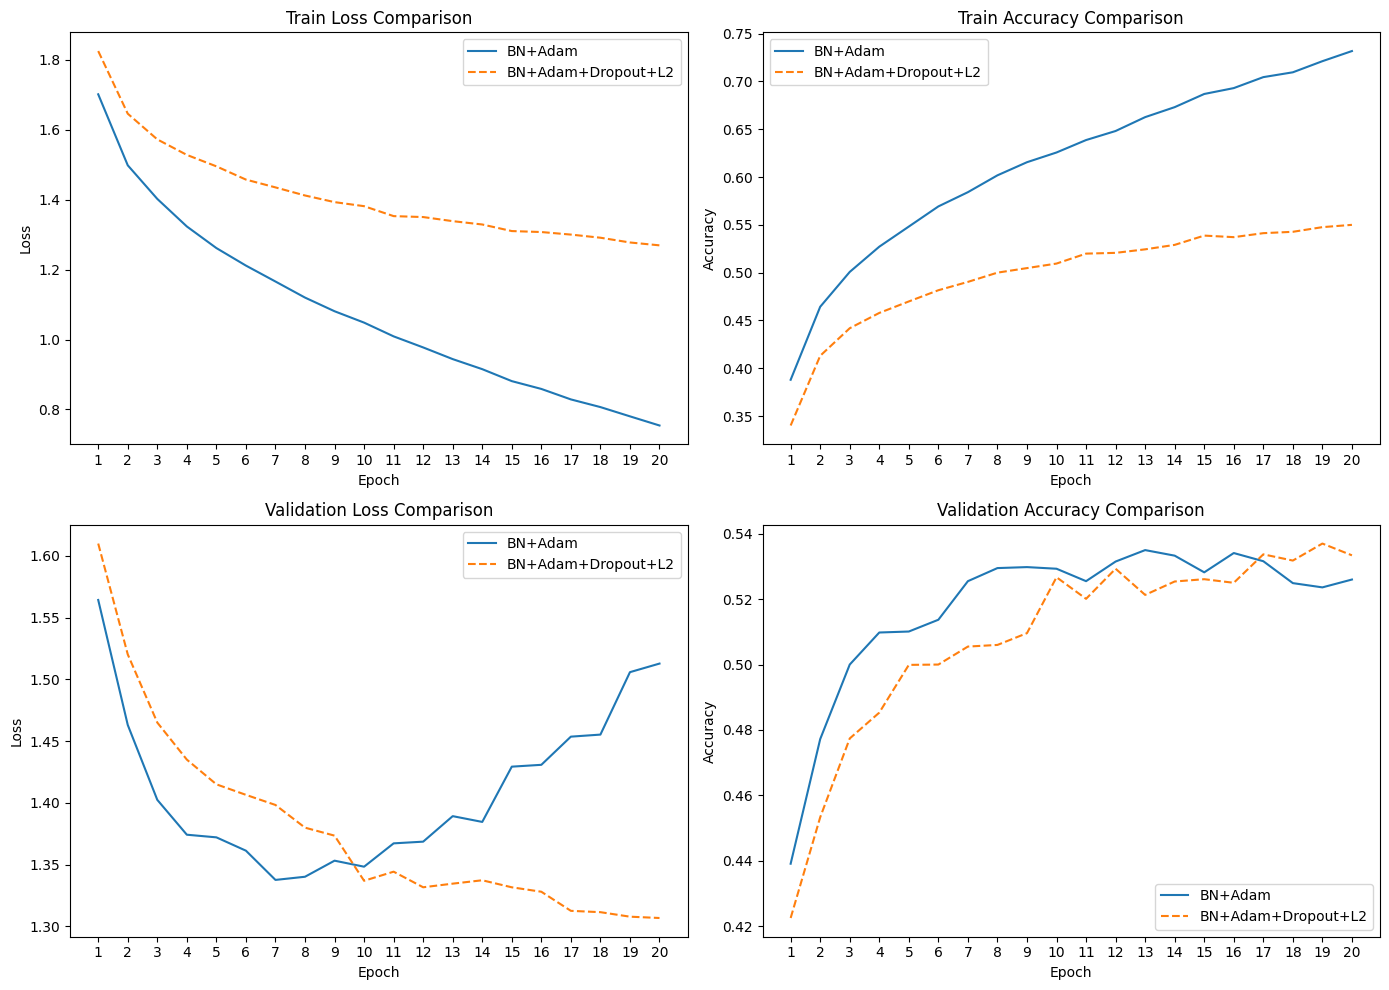

In [21]:
plt.figure(figsize=(14, 10))

# 1. Train Loss
plt.subplot(2, 2, 1)
plt.plot(eval_opt_results["Adam"][0], label="BN+Adam")
plt.plot(results_dropout_l2[0], label="BN+Adam+Dropout+L2", linestyle='--')
plt.title("Train Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(range(0, len(eval_opt_results["Adam"][0])), labels=range(1, len(eval_opt_results["Adam"][0]) + 1))  # integer ticks
plt.legend()

# 2. Train Accuracy
plt.subplot(2, 2, 2)
plt.plot(eval_opt_results["Adam"][2], label="BN+Adam")
plt.plot(results_dropout_l2[2], label="BN+Adam+Dropout+L2", linestyle='--')
plt.title("Train Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(range(0, len(eval_opt_results["Adam"][2])), labels=range(1, len(eval_opt_results["Adam"][2]) + 1))
plt.legend()

# 3. Validation Loss
plt.subplot(2, 2, 3)
plt.plot(eval_opt_results["Adam"][1], label="BN+Adam")
plt.plot(results_dropout_l2[1], label="BN+Adam+Dropout+L2", linestyle='--')
plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(range(0, len(eval_opt_results["Adam"][1])), labels=range(1, len(eval_opt_results["Adam"][1]) + 1))
plt.legend()

# 4. Validation Accuracy
plt.subplot(2, 2, 4)
plt.plot(eval_opt_results["Adam"][3], label="BN+Adam")
plt.plot(results_dropout_l2[3], label="BN+Adam+Dropout+L2", linestyle='--')
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(range(0, len(eval_opt_results["Adam"][3])), labels=range(1, len(eval_opt_results["Adam"][3]) + 1))
plt.legend()

plt.tight_layout()
plt.show()

In [22]:
_, _, _, _, model_bestopt = train_model_with_optimizer("Adam", epochs=20)
_, _, _, _, model_reg = train_dropout_l2_model(epochs=20)

[Adam] Epoch 1/20 - Train Acc: 0.3880, Val Acc: 0.4421
[Adam] Epoch 2/20 - Train Acc: 0.4693, Val Acc: 0.4798
[Adam] Epoch 3/20 - Train Acc: 0.5016, Val Acc: 0.4824
[Adam] Epoch 4/20 - Train Acc: 0.5271, Val Acc: 0.4985
[Adam] Epoch 5/20 - Train Acc: 0.5512, Val Acc: 0.5081
[Adam] Epoch 6/20 - Train Acc: 0.5689, Val Acc: 0.5187
[Adam] Epoch 7/20 - Train Acc: 0.5844, Val Acc: 0.5184
[Adam] Epoch 8/20 - Train Acc: 0.6013, Val Acc: 0.5253
[Adam] Epoch 9/20 - Train Acc: 0.6182, Val Acc: 0.5188
[Adam] Epoch 10/20 - Train Acc: 0.6294, Val Acc: 0.5333
[Adam] Epoch 11/20 - Train Acc: 0.6446, Val Acc: 0.5300
[Adam] Epoch 12/20 - Train Acc: 0.6523, Val Acc: 0.5296
[Adam] Epoch 13/20 - Train Acc: 0.6630, Val Acc: 0.5287
[Adam] Epoch 14/20 - Train Acc: 0.6757, Val Acc: 0.5282
[Adam] Epoch 15/20 - Train Acc: 0.6853, Val Acc: 0.5254
[Adam] Epoch 16/20 - Train Acc: 0.7007, Val Acc: 0.5308
[Adam] Epoch 17/20 - Train Acc: 0.7046, Val Acc: 0.5320
[Adam] Epoch 18/20 - Train Acc: 0.7149, Val Acc: 0.5224
[

In [24]:
def evaluate_model(model, dataloader, name="Model"):
    model.eval()
    all_preds, all_labels = [], []
    start_time = time.time()

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    duration = time.time() - start_time
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')

    print(f"🔍 {name} | Test Accuracy: {acc:.4f} | Macro F1: {f1:.4f} | Inference Time: {duration:.2f}s")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    return acc, f1, duration

In [25]:
model_baseline = eval_opt_results["SGD"][4]                # Baseline: SGD without momentum
model_bn = eval_opt_results["SGD_momentum"][4]             # With BatchNorm + SGD+momentum
model_bestopt = eval_opt_results["Adam"][4]                # With BatchNorm + Adam
model_reg = results_dropout_l2[4]                 # With BN + Adam + Dropout + L2

# Evaluate each model
eval_results = []
models_to_evaluate = [
    ("Baseline (SGD)", model_baseline),
    ("BN (SGD+Momentum)", model_bn),
    ("BN + Adam", model_bestopt),
    ("BN + Adam + Dropout + L2", model_reg)
]

for name, model in models_to_evaluate:
    acc, f1, duration = evaluate_model(model, test_loader, name)
    eval_results.append((name, acc, f1, duration))

🔍 Baseline (SGD) | Test Accuracy: 0.5151 | Macro F1: 0.5127 | Inference Time: 0.46s
              precision    recall  f1-score   support

    airplane       0.54      0.61      0.58      1000
  automobile       0.61      0.60      0.61      1000
        bird       0.44      0.33      0.37      1000
         cat       0.35      0.40      0.37      1000
        deer       0.45      0.48      0.46      1000
         dog       0.44      0.37      0.40      1000
        frog       0.58      0.52      0.55      1000
       horse       0.55      0.59      0.57      1000
        ship       0.64      0.67      0.65      1000
       truck       0.54      0.59      0.56      1000

    accuracy                           0.52     10000
   macro avg       0.51      0.52      0.51     10000
weighted avg       0.51      0.52      0.51     10000

🔍 BN (SGD+Momentum) | Test Accuracy: 0.5231 | Macro F1: 0.5226 | Inference Time: 0.45s
              precision    recall  f1-score   support

    airplane   

In [26]:
df_results = pd.DataFrame(eval_results, columns=["Model", "Accuracy", "Macro F1", "Time (s)"])
print(df_results)

                      Model  Accuracy  Macro F1  Time (s)
0            Baseline (SGD)    0.5151  0.512720  0.460120
1         BN (SGD+Momentum)    0.5231  0.522624  0.447943
2                 BN + Adam    0.5327  0.531906  0.644204
3  BN + Adam + Dropout + L2    0.5397  0.536892  0.377358


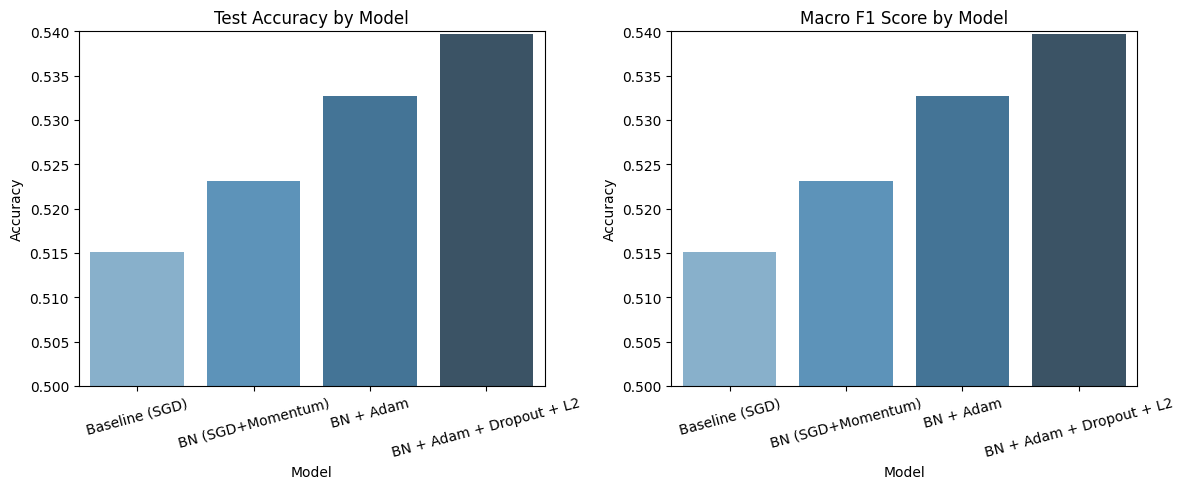

In [27]:
# Bar plot comparison
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
sns.barplot(data=df_results, x="Model", y="Accuracy", palette="Blues_d", hue="Model", legend=False)
plt.ylim(0.50, 0.54)
plt.title("Test Accuracy by Model")
plt.xticks(rotation=15)

# F1 Score
plt.subplot(1, 2, 2)
sns.barplot(data=df_results, x="Model", y="Accuracy", palette="Blues_d", hue="Model", legend=False)
plt.ylim(0.50, 0.54)
plt.title("Macro F1 Score by Model")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [28]:
# Save model_bestopt
torch.save(model_bestopt.state_dict(), "model_bestopt_NB03.pth")

In [29]:
CT_acc_final, CT_f1_final, CT_time_final = evaluate_model(model_bestopt, test_loader, name="Final Reg Model")

print(f"CT_Final Test Accuracy: {CT_acc_final:.4f}")
print(f"CT_Final Macro F1 Score: {CT_f1_final:.4f}")

🔍 Final Reg Model | Test Accuracy: 0.5327 | Macro F1: 0.5319 | Inference Time: 0.39s
              precision    recall  f1-score   support

    airplane       0.57      0.60      0.58      1000
  automobile       0.64      0.62      0.63      1000
        bird       0.43      0.43      0.43      1000
         cat       0.38      0.35      0.36      1000
        deer       0.45      0.48      0.46      1000
         dog       0.47      0.45      0.46      1000
        frog       0.60      0.55      0.58      1000
       horse       0.55      0.64      0.59      1000
        ship       0.67      0.65      0.66      1000
       truck       0.57      0.57      0.57      1000

    accuracy                           0.53     10000
   macro avg       0.53      0.53      0.53     10000
weighted avg       0.53      0.53      0.53     10000

CT_Final Test Accuracy: 0.5327
CT_Final Macro F1 Score: 0.5319
